In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [ ]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched.csv")

In [ ]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,976,True,0,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,6461,True,0,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,3416,True,0,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,923,True,0,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,15957,True,0,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020


In [ ]:
df['gdp'].unique()

array([6.98564394e+03, 4.00287342e+04, 6.44015074e+04, 4.87164099e+04,
       8.84127075e+03, 2.72339427e+04, 3.71738754e+04, 1.06274638e+04,
       5.34679277e+04, 4.04048062e+04, 6.76900000e+11, 6.14100793e+04,
       3.17212989e+04, 5.17915402e+04, 5.33968711e+03, 4.35378393e+04,
       3.91698606e+04, 4.73797652e+04, 3.20914867e+04, 1.28874357e+04,
       4.33600211e+04, 5.22656542e+04, 8.00561288e+04, 7.13074017e+04,
       6.01419881e+04, 6.06077789e+04, 5.28866616e+04, 7.05720755e+03,
       6.22262164e+03, 3.68525425e+04, 1.03140507e+04, 4.69264757e+04,
       7.76900000e+11, 4.37251000e+04, 4.00945600e+04, 3.51255225e+04,
       3.07994776e+04, 5.36487191e+04, 5.62568007e+04, 5.91233186e+04,
       6.49970137e+04, 3.02702687e+04, 4.98990653e+04, 7.78609113e+04,
       9.02990695e+04, 4.60629914e+04, 1.29706056e+04, 6.90935282e+03,
       1.14021410e+04, 4.10828119e+04, 3.40656439e+04, 6.68044507e+03,
       3.23946834e+04, 4.96861155e+04, 5.21766649e+04, 3.56539042e+04,
      

In [ ]:
df['gdp'].describe()


count    1.040200e+06
mean     1.907144e+10
std      1.549602e+11
min      5.339687e+03
25%      3.383618e+04
50%      4.920081e+04
75%      6.457201e+04
max      1.869700e+12
Name: gdp, dtype: float64

In [ ]:
df.sort_values('gdp', ascending=False).head(10)


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year
1040138,HQ-15003,2024-11-12,ST-71,P-9,5,MacBook Pro (Touch Bar),2024-06-17,1304,Apple Yeouido,Seoul,...,6520,False,148,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893834,RH-03176,2024-03-07,ST-71,P-53,1,Apple Watch Series 5,2023-11-10,1296,Apple Yeouido,Seoul,...,1296,False,118,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893805,IW-0153,2024-03-07,ST-70,P-23,6,iPad (9th Generation),2022-03-08,1949,Apple Gangnam,Seoul,...,11694,False,730,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
1040075,PJ-161238,2024-11-12,ST-71,P-14,6,AirPods Pro (2nd Generation),2021-01-29,696,Apple Yeouido,Seoul,...,4176,False,1383,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
1040034,OI-947766,2024-11-12,ST-70,P-45,8,Apple Watch Series 9,2020-09-12,1014,Apple Gangnam,Seoul,...,8112,False,1522,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893794,VB-96996,2024-03-07,ST-70,P-60,3,iMac with Retina Display,2020-07-24,343,Apple Gangnam,Seoul,...,1029,False,1322,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918450,RJ-90927,2024-04-18,ST-71,P-44,1,iPhone 12 Pro Max,2020-09-09,544,Apple Yeouido,Seoul,...,544,False,1317,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918306,IC-329999,2024-04-18,ST-70,P-9,9,MacBook Pro (Touch Bar),2020-01-01,1304,Apple Gangnam,Seoul,...,11736,True,1569,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918309,KB-96957,2024-04-18,ST-70,P-66,10,Mac Mini (M2),2021-10-30,874,Apple Gangnam,Seoul,...,8740,False,901,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918477,YY-879356,2024-04-18,ST-71,P-55,1,Apple TV HD,2021-11-24,1258,Apple Yeouido,Seoul,...,1258,False,876,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024


In [ ]:
import numpy as np

# أكبر قيمة
print("Max GDP:", df['gdp'].max())

# عدد القيم اللي أكبر من 200 ألف
large_values = df[df['gdp'] > 200_000]
print("Count of suspicious large values:", large_values.shape[0])


Max GDP: 1869700000000.0
Count of suspicious large values: 18959


In [ ]:
suspicious_countries = (
    df[df['gdp'] > 200_000]
    .groupby(['country_norm_mapped', 'year'])['gdp']
    .max()
    .reset_index()
    .sort_values('gdp', ascending=False)
)

print(suspicious_countries)


  country_norm_mapped  year           gdp
0         korea, rep.  2024  1.869700e+12
5              taiwan  2024  7.970000e+11
2              taiwan  2021  7.769000e+11
3              taiwan  2022  7.656000e+11
4              taiwan  2023  7.573000e+11
1              taiwan  2020  6.769000e+11


In [ ]:
df['gdp_type'] = np.where(df['gdp'] > 200_000,
                          'GDP_total',
                          'GDP_per_capita')


In [ ]:
df['gdp_type'].value_counts()


gdp_type
GDP_per_capita    1021241
GDP_total           18959
Name: count, dtype: int64

In [ ]:
import pandas as pd

manual_gdp_pc = pd.DataFrame({
    "country_norm_mapped": ["korea, rep."]*5 + ["taiwan"]*5,
    "year": [2020,2021,2022,2023,2024]*2,
    "gdp_per_capita": [
        31728, 34998, 32394, 33147, 34000,  # Korea
        28371, 33775, 32756, 33907, 35000   # Taiwan
    ]
})

df = df.merge(
    manual_gdp_pc,
    on=["country_norm_mapped", "year"],
    how="left"
)

df['gdp_cleaned'] = df['gdp']

df.loc[df['gdp'] > 200_000, 'gdp_cleaned'] = df['gdp_per_capita']



In [ ]:
df.columns  

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city', 'country',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'gdp', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm', 'country_norm_mapped', 'year',
       'gdp_type', 'gdp_per_capita', 'gdp_cleaned'],
      dtype='object')

In [ ]:
df[df['gdp_cleaned'] > 200_000].shape


(0, 26)

In [ ]:
df['gdp_cleaned'].describe()


count    1.040200e+06
mean     4.680516e+04
std      2.361469e+04
min      5.339687e+03
25%      3.350901e+04
50%      4.904069e+04
75%      6.440748e+04
max      9.067407e+04
Name: gdp_cleaned, dtype: float64

In [ ]:
df.isnull().sum()

sale_id                     0
sale_date                   0
store_id                    0
product_id                  0
quantity                    0
product_name                0
launch_date                 0
price                       0
store_name                  0
city                        0
country                     0
category_id                 0
category_name               0
sales_amount                0
invalid_launch_flag         0
product_age_days            0
gdp                         0
exchange_rate               0
inflation_rate              0
internet_usage_pct     106716
country_norm                0
country_norm_mapped         0
year                        0
gdp_type                    0
gdp_per_capita         998306
gdp_cleaned                 0
dtype: int64

In [ ]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year,gdp_type,gdp_per_capita,gdp_cleaned
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020,GDP_per_capita,NaN,6985.643939
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020,GDP_per_capita,NaN,40028.734170
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020,GDP_per_capita,NaN,64401.507440
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020,GDP_per_capita,NaN,48716.409890
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020,GDP_per_capita,NaN,8841.270751


In [ ]:
df['gdp_per_capita'] = df['gdp_cleaned']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 26 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   sale_id              1040200 non-null  object 
 1   sale_date            1040200 non-null  object 
 2   store_id             1040200 non-null  object 
 3   product_id           1040200 non-null  object 
 4   quantity             1040200 non-null  int64  
 5   product_name         1040200 non-null  object 
 6   launch_date          1040200 non-null  object 
 7   price                1040200 non-null  int64  
 8   store_name           1040200 non-null  object 
 9   city                 1040200 non-null  object 
 10  country              1040200 non-null  object 
 11  category_id          1040200 non-null  object 
 12  category_name        1040200 non-null  object 
 13  sales_amount         1040200 non-null  int64  
 14  invalid_launch_flag  1040200 non-null  bool   
 15

In [ ]:
df.isnull().sum()

sale_id                     0
sale_date                   0
store_id                    0
product_id                  0
quantity                    0
product_name                0
launch_date                 0
price                       0
store_name                  0
city                        0
country                     0
category_id                 0
category_name               0
sales_amount                0
invalid_launch_flag         0
product_age_days            0
gdp                         0
exchange_rate               0
inflation_rate              0
internet_usage_pct     106716
country_norm                0
country_norm_mapped         0
year                        0
gdp_type                    0
gdp_per_capita              0
gdp_cleaned                 0
dtype: int64

In [ ]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year,gdp_type,gdp_per_capita,gdp_cleaned
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020,GDP_per_capita,6985.643939,6985.643939
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020,GDP_per_capita,40028.734170,40028.734170
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020,GDP_per_capita,64401.507440,64401.507440
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020,GDP_per_capita,48716.409890,48716.409890
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020,GDP_per_capita,8841.270751,8841.270751


In [ ]:
df.describe()

,quantity,price,sales_amount,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,gdp_cleaned
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,933484.000000,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.907144e+10,1.542778e+02,3.247802e+00,89.942721,2.021946e+03,4.680516e+04,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,1.549602e+11,6.699082e+02,2.625053e+00,7.678001,1.393893e+00,2.361469e+04,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,5.339687e+03,7.270649e-01,-2.079403e+00,69.795300,2.020000e+03,5.339687e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,3.383618e+04,1.000000e+00,1.233584e+00,86.981500,2.021000e+03,3.350901e+04,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,4.920081e+04,1.349909e+00,2.863910e+00,92.000000,2.022000e+03,4.904069e+04,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,6.457201e+04,7.083998e+00,4.878357e+00,94.693500,2.023000e+03,6.440748e+04,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,1.869700e+12,4.325955e+03,1.173590e+01,100.000000,2.024000e+03,9.067407e+04,9.067407e+04


In [ ]:
df.drop(columns=['gdp', 'gdp_cleaned'], inplace=True)


In [ ]:
df.drop(columns=['country', 'country_norm'], inplace=True)


In [ ]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,933484.000000,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,89.942721,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.678001,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,69.795300,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,86.981500,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,92.000000,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,94.693500,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,100.000000,2.024000e+03,9.067407e+04


In [ ]:
df['internet_usage_pct'] = df.groupby(
    ['country_norm_mapped', 'year']
)['internet_usage_pct'].transform(
    lambda x: x.fillna(x.mean())
)


In [ ]:
df['internet_usage_pct'] = df.groupby(
    'country_norm_mapped'
)['internet_usage_pct'].transform(
    lambda x: x.fillna(x.mean())
)


In [ ]:
df.isna().sum()

sale_id                0
sale_date              0
store_id               0
product_id             0
quantity               0
product_name           0
launch_date            0
price                  0
store_name             0
city                   0
category_id            0
category_name          0
sales_amount           0
invalid_launch_flag    0
product_age_days       0
exchange_rate          0
inflation_rate         0
internet_usage_pct     0
country_norm_mapped    0
year                   0
gdp_type               0
gdp_per_capita         0
dtype: int64

In [ ]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04


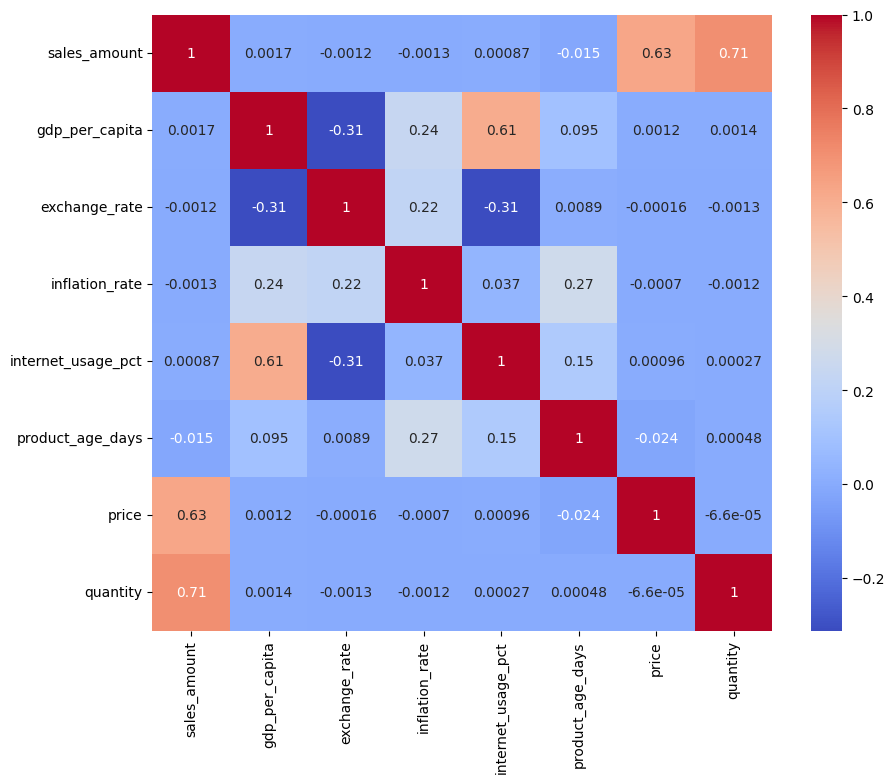

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    df[['sales_amount','gdp_per_capita','exchange_rate',
        'inflation_rate','internet_usage_pct',
        'product_age_days','price','quantity']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()
